In [1]:
import pandas as pd

# Importing Data
To explore the demographic variables and identify potential predictors, we first load the BRFSS 2024 dataset.
The dataset is stored in parquet format and split into two parts due to its large size.

In [2]:
import sys
!{sys.executable} -m pip install pyarrow

In [3]:
import pyarrow.parquet as pq
import pyarrow as pa

# Read as Arrow tables (NOT pandas yet)
t1 = pq.read_table("data_acquisition/BRFSS_2024_1.parquet.gzip")
t2 = pq.read_table("data_acquisition/BRFSS_2024_2.parquet.gzip")

# Concat in Arrow (usually more memory-friendly)
t = pa.concat_tables([t1, t2], promote=True)

# Convert once to pandas
brfss = t.to_pandas(split_blocks=True, self_destruct=True)

# Optional: free arrow tables
del t1, t2, t

C:\Users\Akhil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\interactiveshell.py:3701: FutureWarning: promote has been superseded by promote_options='default'.
  exec(code_obj, self.user_global_ns, self.user_ns)


# Inspecting the Dataset
Inspecting the dataset to know about the Number of rows and columns, data types in each column, the memory usage and combining both datasets into one dataset.

In [4]:
brfss.info()

<class 'pandas.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Columns: 301 entries, _STATE to _AIDTST4
dtypes: float64(296), object(5)
memory usage: 1.0+ GB


In [5]:
brfss.describe()

,_STATE,FMONTH,DISPCODE,_PSU,CTELENM1,PVTRESD1,COLGHOUS,STATERE1,CELPHON1,LADULT1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
count,457670.000000,457670.000000,457670.000000,4.576700e+05,81730.0,81730.000000,14.0,81730.0,81730.0,81730.000000,...,393433.000000,406226.000000,457670.000000,4.576690e+05,457670.000000,4.576700e+05,457670.000000,179344.000000,179344.000000,414178.000000
mean,30.823537,6.426995,1118.669784,2.024007e+09,1.0,1.000171,1.0,1.0,2.0,1.001835,...,3.420252,8.468687,2.196764,1.000599e+02,1.948965,1.044393e+04,1.869063,2.336850,2.462223,1.999684
std,15.939364,3.356938,38.966920,7.488291e+03,0.0,0.013087,0.0,0.0,0.0,0.042801,...,0.792956,1.892208,2.226566,2.613717e+02,2.418721,3.016653e+04,2.414067,2.602255,2.814818,1.665037
min,1.000000,1.000000,1100.000000,2.024000e+09,1.0,1.000000,1.0,1.0,2.0,1.000000,...,1.000000,1.000000,1.000000,5.397605e-79,1.000000,5.397605e-79,1.000000,1.000000,1.000000,1.000000
25%,18.000000,4.000000,1100.000000,2.024002e+09,1.0,1.000000,1.0,1.0,2.0,1.000000,...,3.000000,9.000000,1.000000,5.397605e-79,1.000000,5.397605e-79,1.000000,1.000000,1.000000,1.000000
50%,31.000000,7.000000,1100.000000,2.024005e+09,1.0,1.000000,1.0,1.0,2.0,1.000000,...,4.000000,9.000000,2.000000,3.000000e+00,1.000000,4.700000e+01,1.000000,1.000000,1.000000,2.000000
75%,44.000000,9.000000,1100.000000,2.024008e+09,1.0,1.000000,1.0,1.0,2.0,1.000000,...,4.000000,9.000000,2.000000,2.900000e+01,1.000000,4.670000e+02,1.000000,2.000000,2.000000,2.000000
max,78.000000,12.000000,1200.000000,2.024044e+09,1.0,2.000000,1.0,1.0,2.0,2.000000,...,4.000000,9.000000,9.000000,9.000000e+02,9.000000,9.990000e+04,9.000000,9.000000,9.000000,9.000000


# Inspecting Dataset Variables

The BRFSS dataset contains hundreds of variables collected through health surveys.
To identify relevant demographic and behavioral features, we first examine all available column names in the dataset.

In [5]:
# Displaying all column names
for col in brfss.columns: print(col)

_STATE
FMONTH
IDATE
IMONTH
IDAY
IYEAR
DISPCODE
SEQNO
_PSU
CTELENM1
PVTRESD1
COLGHOUS
STATERE1
CELPHON1
LADULT1
NUMADULT
RESPSLC1
LANDSEX3
SAFETIME
CTELNUM1
CELLFON5
CADULT1
CELLSEX3
PVTRESD3
CCLGHOUS
CSTATE1
LANDLINE
HHADULT
SEXVAR
GENHLTH
PHYSHLTH
MENTHLTH
POORHLTH
PRIMINS2
PERSDOC3
MEDCOST1
CHECKUP1
EXERANY2
LASTDEN4
RMVTETH4
CVDINFR4
CVDCRHD4
CVDSTRK3
ASTHMA3
ASTHNOW
CHCSCNC1
CHCOCNC1
CHCCOPD3
ADDEPEV3
CHCKDNY2
HAVARTH4
DIABETE4
DIABAGE4
MARITAL
EDUCA
RENTHOM1
NUMHHOL4
NUMPHON4
CPDEMO1C
VETERAN3
EMPLOY1
CHILDREN
INCOME3
PREGNANT
WEIGHT2
HEIGHT3
DEAF
BLIND
DECIDE
DIFFWALK
DIFFDRES
DIFFALON
HADMAM
HOWLONG
CERVSCRN
CRVCLCNC
CRVCLPAP
CRVCLHPV
HADHYST2
HADSIGM4
COLNSIGM
COLNTES1
SIGMTES1
LASTSIG4
COLNCNCR
VIRCOLO1
VCLNTES2
SMALSTOL
STOLTEST
STOOLDN2
BLDSTFIT
SDNATES1
SMOKE100
SMOKDAY2
USENOW3
ECIGNOW3
LCSFIRST
LCSNUMCG
LCSCTSC1
LCSSCNCR
LCSCTWHN
ALCDAY4
AVEDRNK4
DRNK3GE5
MAXDRNKS
FLUSHOT7
FLSHTMY3
IMFVPLA5
PNEUVAC4
HIVTST7
HIVTSTD3
HIVRISK5
PDIABTS1
PREDIAB2
DIABTYPE
INSULIN1
CHKHEMO3
EY

# Reviewing Demographic Variables

One of the objectives of Milestone 1 is to review demographic variables that describe the characteristics of survey respondents.
Demographic variables help understand how factors such as age, sex, education, and income influence health outcomes.

The following demographic variables were selected based on the BRFSS codebook:
 - _AGE_G: Age group
 - _SEX: Sex of respondent
 - _EDUCAG: Education Level
 - _INCOMG1: Household Income category

In [6]:
demographic_vars = ["_AGE_G","_SEX","_EDUCAG","_INCOMG1"]
brfss[demographic_vars].head()

,_AGE_G,_SEX,_EDUCAG,_INCOMG1
0,6.0,2.0,2.0,9.0
1,6.0,1.0,4.0,7.0
2,5.0,1.0,3.0,9.0
3,6.0,1.0,4.0,4.0
4,4.0,1.0,3.0,2.0


In [7]:
brfss[demographic_vars].describe()

,_AGE_G,_SEX,_EDUCAG,_INCOMG1
count,457670.000000,457670.000000,457670.000000,457670.000000
mean,4.385527,1.524751,3.077680,5.381790
std,1.640169,0.499388,1.043475,2.282375
min,1.000000,1.000000,1.000000,1.000000
25%,3.000000,1.000000,2.000000,4.000000
50%,5.000000,2.000000,3.000000,5.000000
75%,6.000000,2.000000,4.000000,7.000000
max,6.000000,2.000000,9.000000,9.000000


# Demographic Frequency Distribution

To understand the structure of the dataset, we inspect the frequency distribution of demographic variables.
This helps identify class balance and potential biases in the survey population.

In [8]:
for var in demographic_vars:
    print("\n", var)
    print(brfss[var].value_counts(dropna=False))


 _AGE_G
_AGE_G
6.0    172826
5.0     80280
4.0     64458
3.0     60418
2.0     49994
1.0     29694
Name: count, dtype: int64

 _SEX
_SEX
2.0    240163
1.0    217507
Name: count, dtype: int64

 _EDUCAG
_EDUCAG
4.0    191549
3.0    120732
2.0    115877
1.0     27149
9.0      2363
Name: count, dtype: int64

 _INCOMG1
_INCOMG1
5.0    112409
9.0     87423
6.0     82453
4.0     49686
3.0     41702
2.0     33503
7.0     29694
1.0     20800
Name: count, dtype: int64


# Renaming Demographic Variables

In [9]:
brfss_clean = brfss.rename(columns={
    "_AGE_G": "Age_group",
    "_SEX": "Sex",
    "_EDUCAG": "Education_level",
    "_INCOMG1": "Income_Cat"
})


# Converting Demographic Codes to Categorical Variables

The BRFSS dataset stores many categorical responses as numeric codes.
These codes are mapped to meaningful category labels to improve interpretability.

In [10]:
age_order = [
    "Age 18 to 24",
    "Age 25 to 34",
    "Age 35 to 44",
    "Age 45 to 54",
    "Age 55 to 64",
    "Age 65 or older"
]

brfss_clean["Age_group"] = brfss_clean["Age_group"].astype("Int64")

brfss_clean["Age_group"] = pd.Categorical(
    brfss_clean["Age_group"].map({
        1: "Age 18 to 24",
        2: "Age 25 to 34",
        3: "Age 35 to 44",
        4: "Age 45 to 54",
        5: "Age 55 to 64",
        6: "Age 65 or older"
    }),
    categories=age_order,
    ordered=True
)

In [11]:
brfss_clean["Sex"] = brfss_clean["Sex"].astype("Int64")

brfss_clean["Sex"] = brfss_clean["Sex"].map({
    1: "Male",
    2: "Female"
}).astype("category")

In [12]:
education_order = [
    "Did not graduate High School",
    "Graduated High School",
    "Attended College or Technical School",
    "Graduated from College or Technical School"
]

brfss_clean["Education_level"] = brfss_clean["Education_level"].astype("Int64")

brfss_clean["Education_level"] = pd.Categorical(
    brfss_clean["Education_level"].map({
        1: "Did not graduate High School",
        2: "Graduated High School",
        3: "Attended College or Technical School",
        4: "Graduated from College or Technical School"
    }),
    categories=education_order,
    ordered=True
)

In [13]:
income_order = [
    "Less than $15,000",
    "$15,000 < $25,000",
    "$25,000 < $35,000",
    "$35,000 < $50,000",
    "$50,000 < $100,000",
    "$100,000 < $200,000",
    "$200,000 or more"
]

brfss_clean["Income_Cat"] = brfss_clean["Income_Cat"].astype("Int64")

brfss_clean["Income_Cat"] = pd.Categorical(
    brfss_clean["Income_Cat"].map({
        1: "Less than $15,000",
        2: "$15,000 < $25,000",
        3: "$25,000 < $35,000",
        4: "$35,000 < $50,000",
        5: "$50,000 < $100,000",
        6: "$100,000 < $200,000",
        7: "$200,000 or more"
    }),
    categories=income_order,
    ordered=True
)

In [14]:
brfss_clean.describe(include="category")

,Sex,Age_group,Education_level,Income_Cat
count,457670,457670,455307,370247
unique,2,6,4,7
top,Female,Age 65 or older,Graduated from College or Technical School,"$50,000 < $100,000"
freq,240163,172826,191549,112409


# Demographic Variable Visualization

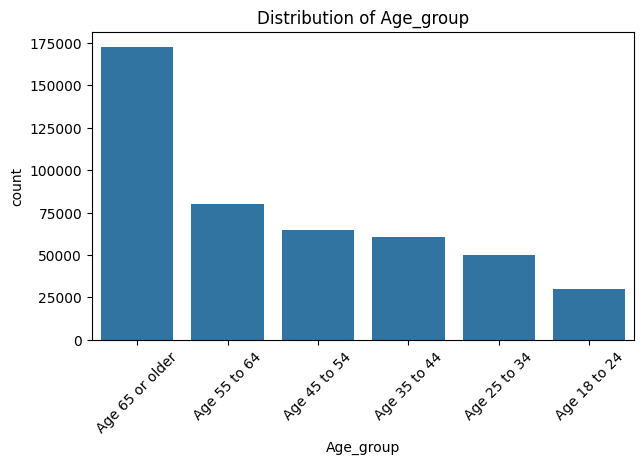

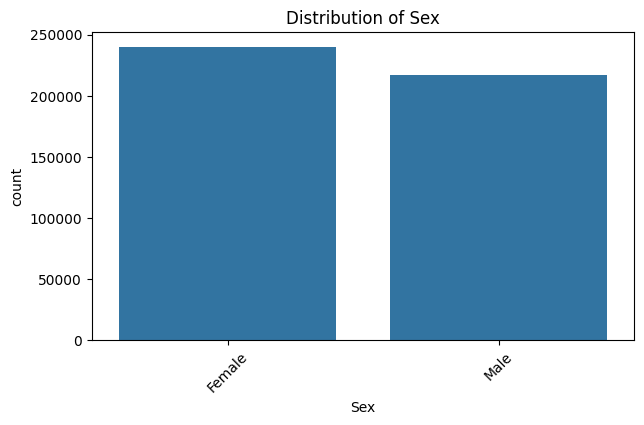

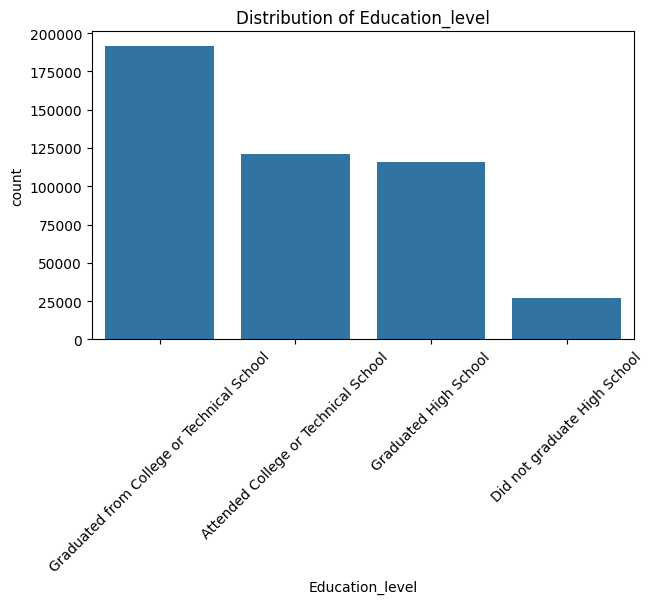

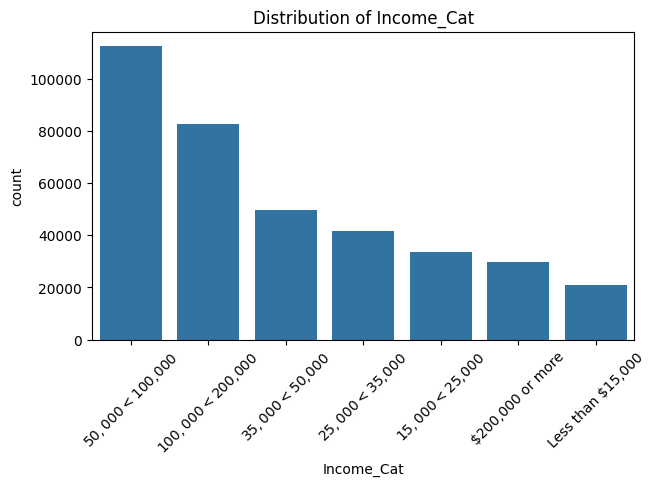

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

demo_vars = ["Age_group","Sex","Education_level","Income_Cat"]

for var in demo_vars:
    plt.figure(figsize=(7,4))
    sns.countplot(x=brfss_clean[var], order=brfss_clean[var].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {var}")
    plt.show()

# Behavioral Risk Factor Review

Behavioral and lifestyle variables play an important role in obesity risk.

The following behavioral predictors are examined:

• Physical Activity  
• Smoking Status  
• Heavy Drinking

These variables represent modifiable health behaviors that may influence obesity outcomes.

In [16]:
# Renaming behavioral variables for readability

brfss_clean = brfss_clean.rename(columns={
    "_TOTINDA": "Physical_Activity",
    "_RFSMOK3": "Smoker",
    "_RFDRHV9": "Heavy_Drinker"
})


In [17]:
behavior_vars = ["Physical_Activity","Smoker","Heavy_Drinker"]

for var in behavior_vars:
    print("\n", var)
    print(brfss_clean[var].value_counts(dropna=False))


 Physical_Activity
Physical_Activity
1.0    350061
2.0    106294
9.0      1315
Name: count, dtype: int64

 Smoker
Smoker
1.0    378554
2.0     47094
9.0     32022
Name: count, dtype: int64

 Heavy_Drinker
Heavy_Drinker
1.0    386812
9.0     46698
2.0     24160
Name: count, dtype: int64


In [18]:
# Converting behavioral variables to categorical

brfss_clean["Physical_Activity"] = brfss_clean["Physical_Activity"].astype("Int64")
brfss_clean["Smoker"] = brfss_clean["Smoker"].astype("Int64")
brfss_clean["Heavy_Drinker"] = brfss_clean["Heavy_Drinker"].astype("Int64")


brfss_clean["Physical_Activity"] = brfss_clean["Physical_Activity"].map({
    1: "Had physical activity",
    2: "No physical activity"
}).astype("category")


brfss_clean["Smoker"] = brfss_clean["Smoker"].map({
    1: "No",
    2: "Yes"
}).astype("category")


brfss_clean["Heavy_Drinker"] = brfss_clean["Heavy_Drinker"].map({
    1: "No",
    2: "Yes"
}).astype("category")

In [19]:
brfss_clean.describe(include="category")

,Physical_Activity,Sex,Age_group,Education_level,Income_Cat,Smoker,Heavy_Drinker
count,456355,457670,457670,455307,370247,425648,410972
unique,2,2,6,4,7,2,2
top,Had physical activity,Female,Age 65 or older,Graduated from College or Technical School,"$50,000 < $100,000",No,No
freq,350061,240163,172826,191549,112409,378554,386812


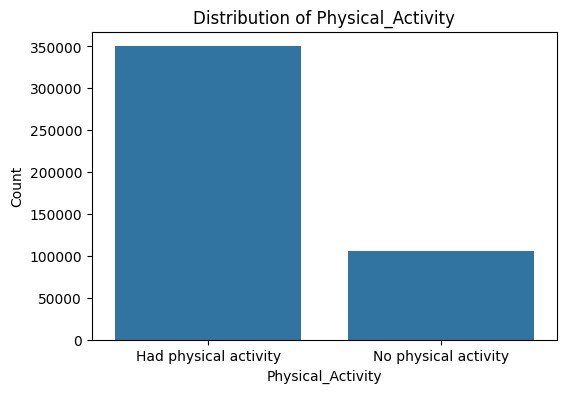

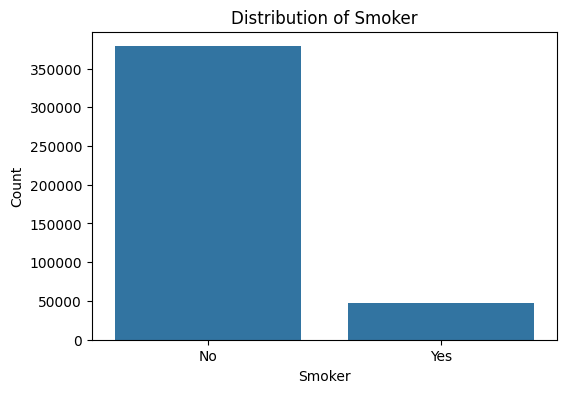

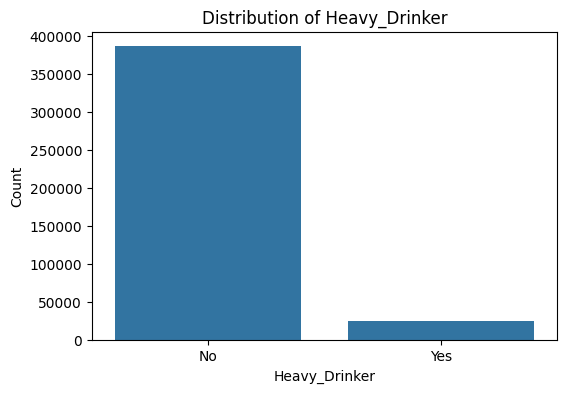

In [20]:

for var in behavior_vars:
    
    plt.figure(figsize=(6,4))
    sns.countplot(x=brfss_clean[var])
    
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Count")
    
    plt.show()

# Numeric Health Variable Review

In [21]:
# Renaming the health variables
brfss_clean = brfss_clean.rename(columns={
    "_BMI5": "BMI_raw",
    "HTM4": "Height_raw",
    "WTKG3": "Weight_raw"
})

In [22]:
# Converting them to Real Units
brfss_clean["BMI"] = brfss_clean["BMI_raw"] / 100
brfss_clean["Height(m)"] = brfss_clean["Height_raw"] / 100
brfss_clean["Weight(kg)"] = brfss_clean["Weight_raw"] / 100

/tmp/ipykernel_137433/3700978480.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brfss_clean["BMI"] = brfss_clean["BMI_raw"] / 100
/tmp/ipykernel_137433/3700978480.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brfss_clean["Height(m)"] = brfss_clean["Height_raw"] / 100
/tmp/ipykernel_137433/3700978480.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.

In [23]:
numeric_vars = ["BMI", "Height(m)", "Weight(kg)"]
brfss_clean[numeric_vars].describe()

,BMI,Height(m),Weight(kg)
count,414633.000000,433610.000000,421278.000000
mean,28.556801,1.701660,83.004845
std,6.586161,0.108228,21.418338
min,12.000000,0.910000,22.680000
25%,24.140000,1.630000,68.040000
50%,27.440000,1.700000,80.740000
75%,31.750000,1.780000,95.250000
max,99.840000,2.410000,290.300000


# Outlier Detection

Boxplots are used to visually inspect extreme values in BMI, height, and weight.

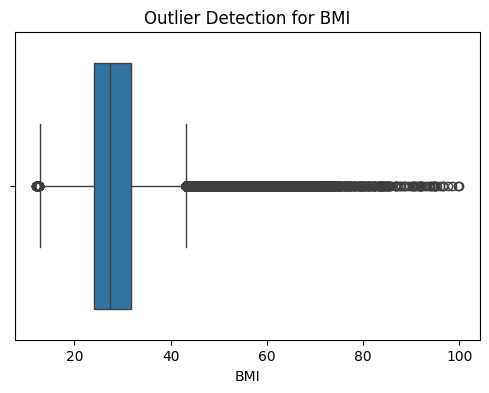

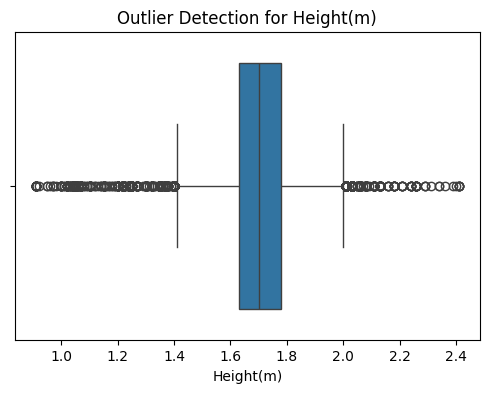

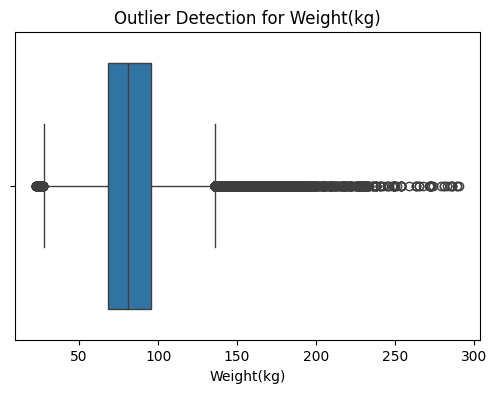

In [24]:

numeric_vars = ["BMI","Height(m)","Weight(kg)"]

for var in numeric_vars:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=brfss_clean[var])

    plt.title(f"Outlier Detection for {var}")
    plt.show()

# Removing Unrealistic Values

Extreme values in BMI, height, and weight may represent data entry errors or unrealistic measurements.  
To improve model stability, unrealistic observations are removed.

In [25]:
brfss_clean = brfss_clean[
    (brfss_clean["BMI"] >= 12) & (brfss_clean["BMI"] <= 60) &
    (brfss_clean["Height(m)"] >= 1.2) & (brfss_clean["Height(m)"] <= 2.2) &
    (brfss_clean["Weight(kg)"] >= 35) & (brfss_clean["Weight(kg)"] <= 250)
]

In [26]:
brfss_clean.shape

(413548, 304)

In [27]:
brfss_clean[["BMI","Height(m)","Weight(kg)"]].isna().sum()

BMI           0
Height(m)     0
Weight(kg)    0
dtype: int64

# KNN Imputation

K-Nearest Neighbor (KNN) imputation is a technique used to estimate missing values based on similar observations in the dataset.

Although missing values were not present in the numeric variables after data cleaning, KNN imputation is applied to demonstrate the method used for handling missing data.

In [28]:
numeric_vars = ["BMI", "Height(m)", "Weight(kg)"]

In [29]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

brfss_clean[numeric_vars] = imputer.fit_transform(
    brfss_clean[numeric_vars]
)

In [31]:
brfss_clean[numeric_vars].isna().sum()

BMI           0
Height(m)     0
Weight(kg)    0
dtype: int64

In [32]:
brfss_clean[numeric_vars].head()

,BMI,Height(m),Weight(kg)
0,22.49,1.63,59.42
1,25.83,1.78,81.65
2,22.53,1.98,88.45
3,25.09,1.73,74.84
4,19.77,1.73,58.97


In [33]:
selected_cat = [
    "Age_group",
    "Sex",
    "Education_level",
    "Income_Cat",
    "Physical_Activity",
    "Smoker",
    "Heavy_Drinker"
]

In [34]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

cat_encoded = pd.DataFrame(
    encoder.fit_transform(brfss_clean[selected_cat].astype(str)),
    columns=selected_cat,
    index=brfss_clean.index
)

In [35]:
import numpy as np
from sklearn.impute import KNNImputer

# much smaller to avoid crashes
K = 3
SAMPLE_N = 8000       # try 8000 (or even 5000 if needed)
CHUNK_SIZE = 10000    # try 10k (or 5k if needed)

imputer = KNNImputer(n_neighbors=K)

# IMPORTANT: convert to float32 to cut memory in half
cat_encoded32 = cat_encoded.astype("float32")

# fit on a small sample (heavy step)
cat_sample = cat_encoded32.sample(n=min(SAMPLE_N, len(cat_encoded32)), random_state=42)
imputer.fit(cat_sample)

# create an output container (same shape, no huge vstack later)
cat_imputed_int = pd.DataFrame(index=cat_encoded32.index, columns=selected_cat, dtype="Int64")

# stream through chunks and write results immediately (no big list)
for start in range(0, len(cat_encoded32), CHUNK_SIZE):
    end = min(start + CHUNK_SIZE, len(cat_encoded32))
    chunk = cat_encoded32.iloc[start:end]

    chunk_imp = imputer.transform(chunk)              # returns float
    chunk_imp = np.rint(chunk_imp).astype("int64")    # round to nearest category code

    cat_imputed_int.iloc[start:end, :] = chunk_imp

In [36]:
# convert imputed integer codes back to labels
cat_imputed_labels = pd.DataFrame(
    encoder.inverse_transform(cat_imputed_int.astype(float)),
    columns=selected_cat,
    index=brfss_clean.index
)

# overwrite in your main dataframe
brfss_clean[selected_cat] = cat_imputed_labels[selected_cat]

# set dtype to category for clarity
for col in selected_cat:
    brfss_clean[col] = brfss_clean[col].astype("category")

In [37]:
brfss_clean[selected_cat].isna().sum()

Age_group            0
Sex                  0
Education_level      0
Income_Cat           0
Physical_Activity    0
Smoker               0
Heavy_Drinker        0
dtype: int64

# Target Encoding for High-Cardinality Features

Categorical variables must be encoded into numerical representations before they can be used in machine learning models.
One approach for categorical encoding is target encoding, which is particularly useful for high-cardinality variables (variables with many unique categories).

In this step, we first identify whether any of the selected categorical predictors have high cardinality. If such variables exist, target encoding would be applied.

### Step 1 — Identify Selected Categorical Predictors

In [38]:
selected_cat

['Age_group',
 'Sex',
 'Education_level',
 'Income_Cat',
 'Physical_Activity',
 'Smoker',
 'Heavy_Drinker']

### Step 2 — Evaluate Cardinality of Selected Variables
Cardinality refers to the number of unique categories in a variable.
Variables with a large number of unique categories can create problems for standard encoding methods like one-hot encoding.

In [39]:
cardinality = brfss_clean[selected_cat].nunique(dropna=False).sort_values(ascending=False)

cardinality

Income_Cat           7
Age_group            6
Education_level      4
Sex                  2
Physical_Activity    2
Smoker               2
Heavy_Drinker        2
dtype: int64

### Step 3 — Identify High-Cardinality Features
A common rule in machine learning is to treat variables with more than 10 unique categories as high-cardinality

In [40]:
HIGH_CARD_THRESHOLD = 10

high_card_cols = cardinality[cardinality > HIGH_CARD_THRESHOLD].index.tolist()

high_card_cols

[]

In [41]:
if len(high_card_cols) > 0:
    print("Target encoding would be applied to:", high_card_cols)
else:
    print("No high-cardinality variables detected. Target encoding not required.")

No high-cardinality variables detected. Target encoding not required.


The selected demographic and behavioral predictors were evaluated for cardinality to determine whether target encoding was necessary. The results show that all variables contain fewer than 10 unique categories, indicating that they are low-cardinality categorical features. Because these variables have a small and well-defined set of categories (e.g., binary indicators such as Sex, Smoker, and Heavy_Drinker, and grouped variables such as Age_group and Income_Cat), target encoding would not provide additional benefit. Therefore, target encoding was not applied, and these variables will be handled using simpler categorical encoding methods in later preprocessing steps.

# Scaling Numerical Features
Numerical variables often have different ranges and units. For example, Height, Weight, and BMI operate on different scales.
To ensure that machine learning models treat these variables equally, we apply MinMax Scaling, which rescales each feature to a range between 0 and 1.

### Identifying Numerical Variables
We first define the numerical variables that require scaling.

In [42]:
numeric_vars = ["BMI", "Height(m)", "Weight(kg)"]
numeric_vars

['BMI', 'Height(m)', 'Weight(kg)']

### Step 2 — Inspect Current Range of Values
Before scaling, we check the range of the numerical variables

In [43]:
brfss_clean[numeric_vars].describe()

,BMI,Height(m),Weight(kg)
count,413548.000000,413548.000000,413548.000000
mean,28.472121,1.704078,82.951556
std,6.307705,0.107099,20.868097
min,12.050000,1.200000,35.380000
25%,24.140000,1.630000,68.040000
50%,27.440000,1.700000,80.740000
75%,31.660000,1.780000,95.250000
max,60.000000,2.180000,232.240000


### Step 3 — Apply MinMaxScaler

In [44]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
brfss_clean[numeric_vars] = scaler.fit_transform(brfss_clean[numeric_vars])

### Step 4 — Verifying Scaling
After scaling, the minimum value should be 0 and the maximum value should be 1.

In [45]:
brfss_clean[numeric_vars].describe().loc[["min","max"]]

,BMI,Height(m),Weight(kg)
min,0.0,0.0,0.0
max,1.0,1.0,1.0


The numerical health variables were scaled using MinMaxScaler, which transforms each feature to a range between 0 and 1. This ensures that variables measured on different scales, such as BMI, height, and weight, contribute proportionally during model training. Scaling also helps improve the stability and convergence of many machine learning algorithms. As a result, the dataset is now better prepared for subsequent modeling and analysis

# Outlier Detection and Removal using Isolation Forest
Outliers are observations that significantly deviate from the majority of the data. These extreme values can distort statistical analyses and reduce the performance of machine learning models.

To address this issue, we apply Isolation Forest, an unsupervised anomaly detection algorithm that isolates observations by randomly partitioning the data. Observations that are easier to isolate are more likely to be outliers.

Now that numeric variables have been scaled using MinMaxScaler, we can apply Isolation Forest to detect unusual observations (potential outliers).

### Step 1 — Selecting Numerical Features for Outlier Detection
We apply Isolation Forest only to the key numerical health indicators

In [46]:
brfss_clean[numeric_vars].describe()

,BMI,Height(m),Weight(kg)
count,413548.000000,413548.000000,413548.000000
mean,0.342484,0.514365,0.241652
std,0.131548,0.109285,0.106005
min,0.000000,0.000000,0.000000
25%,0.252138,0.438776,0.165905
50%,0.320959,0.510204,0.230418
75%,0.408968,0.591837,0.304125
max,1.000000,1.000000,1.000000


### Step 2 — Fit Isolation Forest and create an outlier flag

In [47]:
from sklearn.ensemble import IsolationForest

# Isolation Forest on scaled numeric variables
iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,   # 1% of rows flagged as outliers
    random_state=42
)

# Fit + predict (-1 = outlier, 1 = inlier)
brfss_clean["iso_flag"] = iso.fit_predict(brfss_clean[numeric_vars])

# Convert to a clearer binary column (1 = outlier, 0 = normal)
brfss_clean["is_outlier"] = (brfss_clean["iso_flag"] == -1).astype(int)

brfss_clean["is_outlier"].value_counts(dropna=False)

/tmp/ipykernel_137433/1818755107.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brfss_clean["iso_flag"] = iso.fit_predict(brfss_clean[numeric_vars])
/tmp/ipykernel_137433/1818755107.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  brfss_clean["is_outlier"] = (brfss_clean["iso_flag"] == -1).astype(int)


is_outlier
0    409415
1      4133
Name: count, dtype: int64

### Step 3 — Removing outliers

In [49]:
print("Before outlier removal:", brfss_clean.shape)
brfss_clean = brfss_clean.loc[brfss_clean["is_outlier"] == 0]
print("After outlier removal :", brfss_clean.shape)

Before outlier removal: (413548, 306)
After outlier removal : (409415, 306)


### Step 4 — Quick Sanity Checks After Outlier Removal

In [51]:
# Basic dataset check
brfss_clean.shape

(409415, 306)

In [ ]:
# Confirming outliers were removed
brfss_clean["is_outlier"].value_counts(dropna=False)

is_outlier
0    409415
Name: count, dtype: int64

In [ ]:
# Re-checking missingness for key variables
numeric_vars = ["BMI", "Height(m)", "Weight(kg)"]
brfss_clean[numeric_vars].isna().sum()

BMI           0
Height(m)     0
Weight(kg)    0
dtype: int64

In [54]:
# removing helper outlier flag column
brfss_clean.drop(columns=["is_outlier"], inplace=True, errors="ignore")
brfss_clean.shape

(409415, 305)

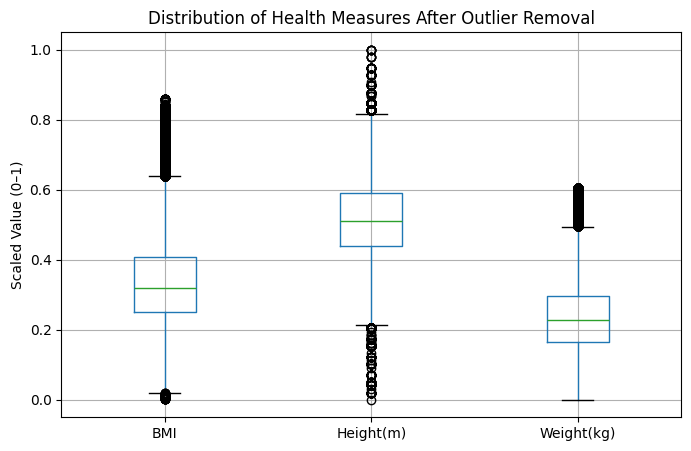

In [58]:
numeric_vars = ["BMI", "Height(m)", "Weight(kg)"]

plt.figure(figsize=(8,5))

brfss_clean[numeric_vars].boxplot()

plt.title("Distribution of Health Measures After Outlier Removal")
plt.ylabel("Scaled Value (0–1)")

plt.show()

The boxplots show the distributions of BMI, height, and weight after applying Isolation Forest for outlier detection and removal. While some points still appear outside the whiskers, these represent univariate deviations based on the IQR rule rather than multivariate anomalies. Isolation Forest evaluates combinations of variables simultaneously, so observations that appear extreme in one variable may still be valid when considered jointly with others. Overall, the distributions are more compact after preprocessing, indicating that extreme multivariate observations were successfully filtered while preserving realistic variability in the health measures.

In [59]:
# Saving cleaned dataset
brfss_clean.to_parquet("brfss_clean_processed.parquet", index=False)